# QRコードのリードソロモン符号でのエンコード手順


<a href="https://colab.research.google.com/github/Tsukumo-999/qr-code-from-scratch/blob/master/Step1/Hello_Encode.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

記事第6回。「[QRコードの作り方を徹底解説｜"HELLO"を例にエンコーダをゼロから実装する【QRコードを解読する 第6回】](https://tukumolog.com/qr-code-encode-tutorial/)」で行った処理を順次確認しながら行えるように、jupyter notebookで試すためのファイルです。

上から順にセルを選択し、"再生ボタン"を押すか、"shift + Enter"で実行できます。

## 1. エンコードの前の設定や文字列の２進数表現
### 1.1 バージョン2、誤り訂正レベルQの基本パラメータを設定します。
今回対象にするQRコードのバージョンは2,誤り訂正レベルはQとしているのでその為のパラメータを設定します。

In [340]:
# QRコードの仕様 (Version 2, Error Correction Level Q)
VERSION = 2
EC_LEVEL = 'Q'
DATA_CODEWORDS_MAX = 22  # V2-Qのデータ領域の最大バイト数（全体が44バイトなので残りの22バイトは後で計算する誤り訂正用）

# モードと文字数指示子の仕様
MODE_INDICATOR = "0100"  # バイトモード(8bit)を示す識別子
CHAR_COUNT_BITS = 8      # Version 1-9のバイトモードでの「文字数」を表すビット長

埋め込む文字の初期設定：HELLO

ASCIIコード（1文字 7bit (0を付加して 8bit = 1byte)）を用いるため、

最大データ容量22byteからヘッダーと終端パターン(0000)の２byteを除いた20byte = 最大20文字入れられます。

In [ ]:
word = "HELLO"
#word = "tukumolog.com" #最近のスマホは賢いのでhttps://を省略してもウェブサイトを開いてくれます。

print(f"エンコード対象: '{word}' 文字数: {len(word)}")
print(f"最大データ容量: {DATA_CODEWORDS_MAX} バイト ({DATA_CODEWORDS_MAX * 8} ビット)")

エンコード対象: 'tukumolog.com' 文字数: 13
最大データ容量: 22 バイト (176 ビット)


### 1.2 ヘッダー情報の定義
QRコードでは何文字の情報が入っているかわからないと、どこからどこまでが元の文字列で、どこからどこまでがパリティなのかわからないので文字列の長さをヘッダー（右下から埋めていくので右下あたり）に配置しています。

In [342]:
# どのようなデータが、何文字入っているかを示すヘッダーを作ります。

char_count = len(word)
# 文字数を2進数表記(8桁0埋め)に変換
char_count_bin = format(char_count, f"0{CHAR_COUNT_BITS}b")

header = MODE_INDICATOR + char_count_bin

print("【ステップ1：ヘッダーの作成】")
print(f"モード指示子: {MODE_INDICATOR} (バイトモード)")
print(f"文字数指示子: {char_count_bin} (文字数: {char_count})")
print(f"→ ヘッダー情報: {header}")

【ステップ1：ヘッダーの作成】
モード指示子: 0100 (バイトモード)
文字数指示子: 00001101 (文字数: 13)
→ ヘッダー情報: 010000001101


### 1.2 データビットの生成（ASCIIコード化）
第３回で説明したASCIIコードで文字列をbit列に読み替えます。

In [343]:

# 文字列 "HELLO" を1文字ずつ8ビットのASCIIコード(2進数)に変換します。

data_bits = ""
print("【ステップ2：文字のデータ化】")
for char in word:
    ascii_val = ord(char)
    bin_val = format(ascii_val, "08b")
    data_bits += bin_val
    print(f" '{char}' (ASCII: {ascii_val:3}) -> {bin_val}")

print(f"→ データビット列: {data_bits}")

【ステップ2：文字のデータ化】
 't' (ASCII: 116) -> 01110100
 'u' (ASCII: 117) -> 01110101
 'k' (ASCII: 107) -> 01101011
 'u' (ASCII: 117) -> 01110101
 'm' (ASCII: 109) -> 01101101
 'o' (ASCII: 111) -> 01101111
 'l' (ASCII: 108) -> 01101100
 'o' (ASCII: 111) -> 01101111
 'g' (ASCII: 103) -> 01100111
 '.' (ASCII:  46) -> 00101110
 'c' (ASCII:  99) -> 01100011
 'o' (ASCII: 111) -> 01101111
 'm' (ASCII: 109) -> 01101101
→ データビット列: 01110100011101010110101101110101011011010110111101101100011011110110011100101110011000110110111101101101


### 1.3 結合と終端パターンの追加
ヘッダーとデータをくっつけ、データの終わりを示す「終端パターン(0000)」を付けます。

In [344]:

# ヘッダーとデータをくっつけ、データの終わりを示す「終端パターン(0000)」を付けます。

bitstream = header + data_bits
print("【ステップ3：結合と終端パターンの追加】")
print(f"結合したビット列: {bitstream} (計{len(bitstream)}ビット)")

# 終端パターン(0000)の追加
# 最大容量に達していない場合、最大4ビットの「0」を追加します。
max_bits = DATA_CODEWORDS_MAX * 8
terminator_length = min(4, max_bits - len(bitstream))
terminator = "0" * terminator_length

bitstream += terminator
print(f"終端 '{terminator}' を追加 : {bitstream} (計{len(bitstream)}ビット)")

【ステップ3：結合と終端パターンの追加】
結合したビット列: 01000000110101110100011101010110101101110101011011010110111101101100011011110110011100101110011000110110111101101101 (計116ビット)
終端 '0000' を追加 : 010000001101011101000111010101101011011101010110110101101111011011000110111101100111001011100110001101101111011011010000 (計120ビット)


### 1.4 8ビットの倍数への調整（ビットパディング）

In [345]:

# コンピュータが扱いやすいよう、8の倍数（バイト単位）になるまで「0」を埋めて切り上げます。

print("【ステップ4：バイト単位への切り上げ】")
remainder = len(bitstream) % 8
if remainder != 0:
    pad_bits = "0" * (8 - remainder)
    bitstream += pad_bits
    print(f"8の倍数にするため '{pad_bits}' を追加:")
    print(f"→ {bitstream} (計{len(bitstream)}ビット)")
else:
    print("すでに8の倍数なので追加なし。")

【ステップ4：バイト単位への切り上げ】
すでに8の倍数なので追加なし。


### 1.5 埋め草（パディングバイト）の追加
qrコードに少ない文字数を入れると、場所が余ります。この部分を0にしてしまうと真っ白になり、読み取り時にうまく検出できなくなったりするため、白黒が適度に出てくるパタンを追加します。

In [346]:

# QRコードの規定容量（今回は22バイト）に達するまで、特定のパターンを交互に埋めていきます。

print("【ステップ5：埋め草バイトの追加】")
# QRコード規格で決まっている埋め草パターン (236 と 17)
PAD_BYTES = ["11101100", "00010001"] 

current_bytes = len(bitstream) // 8
pad_count = DATA_CODEWORDS_MAX - current_bytes

print(f"現在の容量: {current_bytes}バイト / 最大容量: {DATA_CODEWORDS_MAX}バイト")
print(f"空き領域に {pad_count}バイト の埋め草を追加します。\n")

for i in range(pad_count):
    pad_byte = PAD_BYTES[i % 2]
    bitstream += pad_byte
    print(f" 埋め草 {i+1}個目 (0x{int(pad_byte, 2):02X}): {pad_byte}")

print("\n▼ 最終的なデータビット列 ▼")
# 8ビットごとに区切って見やすく表示
formatted_bitstream = " ".join([bitstream[i:i+8] for i in range(0, len(bitstream), 8)])
print(formatted_bitstream)
print(f"(合計: {len(bitstream)} ビット / {len(bitstream)//8} バイト)")

【ステップ5：埋め草バイトの追加】
現在の容量: 15バイト / 最大容量: 22バイト
空き領域に 7バイト の埋め草を追加します。

 埋め草 1個目 (0xEC): 11101100
 埋め草 2個目 (0x11): 00010001
 埋め草 3個目 (0xEC): 11101100
 埋め草 4個目 (0x11): 00010001
 埋め草 5個目 (0xEC): 11101100
 埋め草 6個目 (0x11): 00010001
 埋め草 7個目 (0xEC): 11101100

▼ 最終的なデータビット列 ▼
01000000 11010111 01000111 01010110 10110111 01010110 11010110 11110110 11000110 11110110 01110010 11100110 00110110 11110110 11010000 11101100 00010001 11101100 00010001 11101100 00010001 11101100
(合計: 176 ビット / 22 バイト)


### 1.6 データコード語に整形
リードソロモン符号の計算をするので、計算しやすいように配列に整形しておきます。

In [347]:
# 完成したビット列を、次回の「誤り訂正コード（リード・ソロモン符号）の計算」で
# 使いやすいように、整数の配列（リスト）に変換しておきます。

print("【次回の誤り訂正計算への準備】")
data_codewords = []
for i in range(0, len(bitstream), 8):
    byte_str = bitstream[i:i+8]
    data_codewords.append(int(byte_str, 2))

print("データコード語 (10進数配列):")
print(data_codewords)

print("\nデータコード語 (16進数配列):")
print([f"0x{x:02X}" for x in data_codewords])

【次回の誤り訂正計算への準備】
データコード語 (10進数配列):
[64, 215, 71, 86, 183, 86, 214, 246, 198, 246, 114, 230, 54, 246, 208, 236, 17, 236, 17, 236, 17, 236]

データコード語 (16進数配列):
['0x40', '0xD7', '0x47', '0x56', '0xB7', '0x56', '0xD6', '0xF6', '0xC6', '0xF6', '0x72', '0xE6', '0x36', '0xF6', '0xD0', '0xEC', '0x11', '0xEC', '0x11', '0xEC', '0x11', '0xEC']


## 2. リードソロモン符号の計算

### 2.1 GF(2^8)の演算テーブルの準備
GF(2^8)の演算テーブルと乗算関数をあらかじめ作成しておきます。

In [348]:
# 第5回の「理論編」で作成した指数表と対数表を生成し、
# ガロア体上の乗算を行う関数を定義します。

def generate_galois_tables():
    exp = [0] * 256
    log = [0] * 256
    v = 1
    for i in range(255):
        exp[i] = v
        log[v] = i
        v <<= 1
        if v & 0x100:
            v ^= 0x11D
    exp[255] = exp[0]
    return exp, log

exp_table, log_table = generate_galois_tables()

def gf_mul(x, y):
    """ガロア体 GF(2^8) 上での乗算"""
    if x == 0 or y == 0:
        return 0
    return exp_table[(log_table[x] + log_table[y]) % 255]

print("GF(2^8) の準備が完了しました。")

GF(2^8) の準備が完了しました。


### 2.2 生成多項式 G(x) の算出
誤り訂正レベルQ（バージョン2）では、22バイトの誤り訂正コードが必要です。

そのため、22次の生成多項式 G(x) を計算します。

G(x) = (x - α^0)(x - α^1)...(x - α^21)

In [349]:
num_ec_codewords = 22

# 初期値は G(x) = 1 (多項式表現の配列として [1] からスタート)
G = [1]

for i in range(num_ec_codewords):
    # (x - α^i) を掛けていく処理。ガロア体では加算と減算は同じ(XOR)。
    # α^i は exp_table[i] として取得可能。
    alpha_i = exp_table[i]
    
    # 新しい多項式の係数を格納する配列（掛けるたびに次数が1増える）
    new_G = [0] * (len(G) + 1)
    
    for j, coef in enumerate(G):
        # 1. x を掛ける処理（配列のインデックスが1つ後ろにずれる）
        new_G[j] ^= coef
        
        # 2. α^i を掛ける処理（直前のセルの gf_mul を使用）
        new_G[j + 1] ^= gf_mul(coef, alpha_i)
        
    G = new_G

print(f"【ステップ1】{num_ec_codewords}次の生成多項式 G(x) の係数を算出しました。")

【ステップ1】22次の生成多項式 G(x) の係数を算出しました。


### 2.3 生成多項式 G(x) の確認

In [350]:
# 算出された係数を確認します。これが割り算の「割る数」になります。

print("▼ 生成多項式 G(x) の係数（高次から低次へ） ▼")
formatted_G = [f"0x{c:02X}" for c in G]
print(formatted_G)
print(f"(項数: {len(G)} -> 最高次数は {len(G)-1}次)")

▼ 生成多項式 G(x) の係数（高次から低次へ） ▼
['0x01', '0x59', '0xB3', '0x83', '0xB0', '0xB6', '0xF4', '0x13', '0xBD', '0x45', '0x28', '0x1C', '0x89', '0x1D', '0x7B', '0x43', '0xFD', '0x56', '0xDA', '0xE6', '0x1A', '0x91', '0xF5']
(項数: 23 -> 最高次数は 22次)


### 2.4 メッセージ多項式M(x)の準備
1.6節で作成した"データコード語"を確認し、誤り訂正を入れるための22BYTEの場所を用意してメッセージ多項式M(x)を準備します

In [351]:
# 1.作成したデータ（HELLOをV2-Qでエンコードしてパディングしたもの）
print("データコード語：",data_codewords)
# 後ろに誤り訂正コードを入れるための「器（22個の0）」を用意
msg = data_codewords + [0] * num_ec_codewords

print("【ステップ2】メッセージ多項式 M(x) に x^22 を掛けました（0埋め）")
print(f"全体の長さ: {len(msg)} バイト")
print([f"0x{c:02X}" for c in msg])

データコード語： [64, 215, 71, 86, 183, 86, 214, 246, 198, 246, 114, 230, 54, 246, 208, 236, 17, 236, 17, 236, 17, 236]
【ステップ2】メッセージ多項式 M(x) に x^22 を掛けました（0埋め）
全体の長さ: 44 バイト
['0x40', '0xD7', '0x47', '0x56', '0xB7', '0x56', '0xD6', '0xF6', '0xC6', '0xF6', '0x72', '0xE6', '0x36', '0xF6', '0xD0', '0xEC', '0x11', '0xEC', '0x11', '0xEC', '0x11', '0xEC', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00', '0x00']


### 2.5 【メイン処理】リードソロモン符号の計算
M(x) * x^22 を G(x) で割る、筆算のような処理を行います。

In [352]:
print("【ステップ3】多項式の割り算を実行中...")

# データの長さ（22）の回数だけ、先頭の項を消去する処理を繰り返す
for i in range(len(data_codewords)):
    # 現在注目している先頭の係数
    coef = msg[i]
    
    # 係数が0なら、引く（XORする）必要はないのでスキップ
    if coef != 0:
        # G(x) の各項を coef 倍して、msg から引く（XOR）
        for j in range(len(G)):
            msg[i + j] ^= gf_mul(G[j], coef)

print("割り算が完了しました。")

【ステップ3】多項式の割り算を実行中...
割り算が完了しました。


### 2.6 最終的なQRコードのデータ構造の完成
割り算の「余り（後ろの22バイト）」が、求めていた誤り訂正コードです。

In [353]:
# 余り部分を抽出
ec_codewords = msg[-num_ec_codewords:]

print("▼ 誤り訂正コード（余り） ▼")
print([f"0x{c:02X}" for c in ec_codewords])
print(f"(計 {len(ec_codewords)} バイト)\n")

# データコード語と誤り訂正コードを結合
final_message = data_codewords + ec_codewords

print("▼ 【完成】最終的なデータ列（データ部 ＋ 誤り訂正部） ▼")
print([f"0x{c:02X}" for c in final_message])
print(f"(総容量: {len(final_message)} バイト。これがQRの規格上のV2-Qの最大容量 44バイト と完全に一致します)")

▼ 誤り訂正コード（余り） ▼
['0x08', '0x6B', '0x44', '0x03', '0x15', '0x36', '0x02', '0x11', '0x71', '0x64', '0xA3', '0x66', '0x0D', '0x19', '0x9A', '0x74', '0x5D', '0x18', '0xDB', '0x09', '0xAE', '0xE5']
(計 22 バイト)

▼ 【完成】最終的なデータ列（データ部 ＋ 誤り訂正部） ▼
['0x40', '0xD7', '0x47', '0x56', '0xB7', '0x56', '0xD6', '0xF6', '0xC6', '0xF6', '0x72', '0xE6', '0x36', '0xF6', '0xD0', '0xEC', '0x11', '0xEC', '0x11', '0xEC', '0x11', '0xEC', '0x08', '0x6B', '0x44', '0x03', '0x15', '0x36', '0x02', '0x11', '0x71', '0x64', '0xA3', '0x66', '0x0D', '0x19', '0x9A', '0x74', '0x5D', '0x18', '0xDB', '0x09', '0xAE', '0xE5']
(総容量: 44 バイト。これがQRの規格上のV2-Qの最大容量 44バイト と完全に一致します)


## 3. QRの規格に合わせて画像にする
### 3.1 キャンバス定義と固定パタンの描画

In [354]:
# PILを使って、盤面（matrix）の状態をいつでも画像として確認するための関数

from PIL import Image, ImageDraw
from IPython.display import display

GRID_SIZE = 25  # バージョン2 (4 * 2 + 17 = 25)

# 盤面の初期化。未配置は None とします。
matrix = [[None] * GRID_SIZE for _ in range(GRID_SIZE)]

def show_grid(title="QR Code State",saveimg = False):
    """現在の matrix の状態を画像化してノートブック上に表示するヘルパー関数"""
    scale = 15
    padding = 30
    img_size = GRID_SIZE * scale + 2 * padding
    img = Image.new("RGB", (img_size, img_size), "#E0E0E0")  # 背景色（グレー）
    draw = ImageDraw.Draw(img)
    
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = matrix[y][x]
            
            px = padding + x * scale
            py = padding + y * scale
            box = [px, py, px + scale - 1, py + scale - 1]
            
            # 値に応じて色を変える
            if val == 1:
                color = "black"         # 固定パターン (黒)
            elif val == 0:
                color = "white"         # 固定パターン (白)
            elif val == 2:
                color = "#0052cc"       # データ (黒/青色系)
            elif val == 3:
                color = "#cce0ff"       # データ (白/水色系)
            elif val == 4:
                color = "#ffb3b3"       # 予約領域 (赤)
            else:
                color = "#F5F5F5"       # 未配置 (薄いグレー)
                
            draw.rectangle(box, fill=color, outline="#CCCCCC")
            
    print(f"--- {title} ---")
    display(img)

    # saveimgがtrueの時、画像として保存する。
    if saveimg:
        filename = f"title.png"
        img.save(filename)
        print(f"画像を保存しました: {filename}")

print("キャンバスと描画ツールの準備が完了しました。")

キャンバスと描画ツールの準備が完了しました。


### 3.2 ファインダパタンの配置

 QRコードの3つの角にある大きな目印（ファインダパタン）を配置します。

--- ステップ1: ファインダパタンの配置 ---


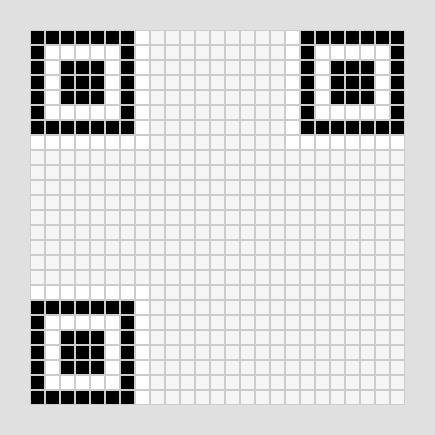

In [355]:
def draw_finder(ox, oy):
    """ファインダパタンと周囲のセパレータ（白枠）を描画"""
    for dy in range(9):
        for dx in range(9):
            x, y = ox + dx, oy + dy
            if 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE:
                if dx == 0 or dx == 8 or dy == 0 or dy == 8:
                    matrix[y][x] = 0  # セパレータ (白)
                elif dx == 1 or dx == 7 or dy == 1 or dy == 7:
                    matrix[y][x] = 1  # 外枠 (黒)
                elif dx == 2 or dx == 6 or dy == 2 or dy == 6:
                    matrix[y][x] = 0  # 内枠 (白)
                else:
                    matrix[y][x] = 1  # 中心 (黒)

# 左上、右上、左下の3箇所に配置
draw_finder(-1, -1)
draw_finder(GRID_SIZE - 8, -1)
draw_finder(-1, GRID_SIZE - 8)

# 結果を確認
show_grid("ステップ1: ファインダパタンの配置")

### 3.3 その他の固定パターンの配置
アライメント（ズレ補正、右下の小さいファインダパタンみたいなやつ）、タイミング（縞模様）、ダークモジュールを配置します。

--- ステップ2: 全ての固定パターンの配置完了 ---


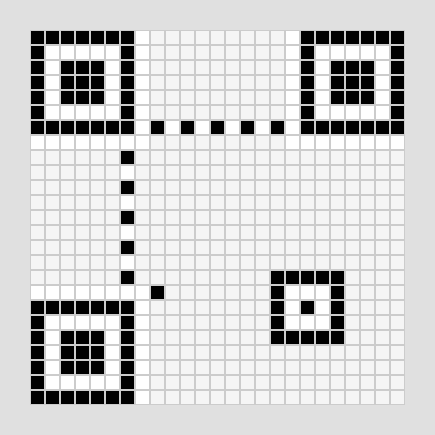

In [356]:
# 1. アライメントパターンの配置 (バージョン2は中心が18,18)
ax, ay = 16, 16
for dy in range(5):
    for dx in range(5):
        x, y = ax + dx, ay + dy
        if dx == 0 or dx == 4 or dy == 0 or dy == 4:
            matrix[y][x] = 1
        elif dx == 2 and dy == 2:
            matrix[y][x] = 1
        else:
            matrix[y][x] = 0

# 2. タイミングパターンの配置 (6行目と6列目を白黒交互に)
for i in range(8, GRID_SIZE - 8):
    if matrix[6][i] is None:
        matrix[6][i] = 1 if i % 2 == 0 else 0
    if matrix[i][6] is None:
        matrix[i][6] = 1 if i % 2 == 0 else 0

# 3. ダークモジュール（必ず黒になる1マス: x=8, y=17）
matrix[17][8] = 1

# 結果を確認
show_grid("ステップ2: 全ての固定パターンの配置完了")

### 3.4 予約領域の定義とデータ配置ルートの取得
データを置いてはいけない場所（マスク情報などが入る予約領域）を定義し、
データを入れていく「ジグザグ」のルートを計算します。

データ配置可能なマス数: 359 ビット
--- ステップ3: 予約領域の確保とデータ配置ルートの計算 ---


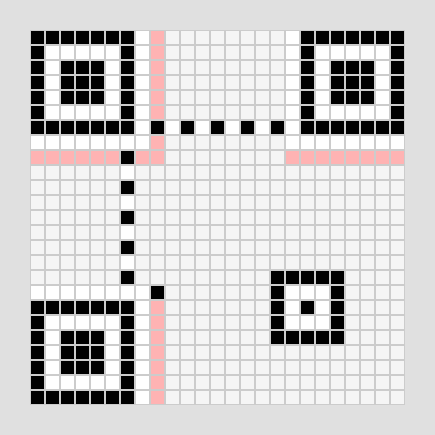

In [357]:
def is_reserved(x, y):
    # すでに固定パターンがある場所
    if matrix[y][x] is not None:
        return True
    
    # フォーマット情報エリア（今回はデータ領域から除外して赤色(4)でマークします）
    is_format_area = False
    if (0 <= x <= 8 and y == 8) or (x == 8 and 0 <= y <= 8):
        is_format_area = True
    if (GRID_SIZE - 8 <= x < GRID_SIZE and y == 8):
        is_format_area = True
    if (x == 8 and GRID_SIZE - 7 <= y < GRID_SIZE):
        is_format_area = True
        
    if is_format_area:
        matrix[y][x] = 4  # 視覚化のために赤色でマーク
        return True
        
    return False

def get_mapping():
    """右下から2列ずつ上・下へジグザグに進む座標リストを取得"""
    available = []
    x = GRID_SIZE - 1
    upward = True
    
    while x > 0:
        if x == 6:  # タイミングパターンの列はスキップ
            x -= 1
            
        y_range = range(GRID_SIZE - 1, -1, -1) if upward else range(GRID_SIZE)
        
        for y in y_range:
            for dx in (0, -1):
                cx = x + dx
                if not is_reserved(cx, y):
                    available.append((cx, y))
                    
        upward = not upward
        x -= 2
        
    return available

mapping = get_mapping()

# 結果を確認（赤色の部分が「予約領域」、薄いグレーが「これからデータが入る場所」です）
print(f"データ配置可能なマス数: {len(mapping)} ビット")
show_grid("ステップ3: 予約領域の確保とデータ配置ルートの計算")

### 3.5 データビットの流し込み
計算されたジグザグのルートに沿って、前回のセクションで作った文字列データを流し込みます。

【ステップ4：データ領域への流し込み】
流し込むデータ(計44バイト):\n[64, 215, 71, 86, 183, 86, 214, 246, 198, 246, 114, 230, 54, 246, 208, 236, 17, 236, 17, 236, 17, 236, 8, 107, 68, 3, 21, 54, 2, 17, 113, 100, 163, 102, 13, 25, 154, 116, 93, 24, 219, 9, 174, 229]\n
--- ステップ4: データ領域への流し込み完了！ ---


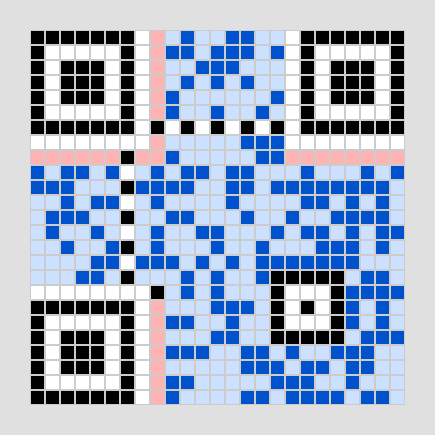

In [358]:
print("【ステップ4：データ領域への流し込み】")
# セクション2.6で完成した final_message をそのまま使用します。
print(f"流し込むデータ(計{len(final_message)}バイト):\\n{final_message}\\n")

# 8ビットずつ展開してフラットな1次元のビット配列にする
bit_stream = []
for byte in final_message:
    for i in range(7, -1, -1):
        bit_stream.append((byte >> i) & 1)

# ジグザグスキャンのルートに従って盤面に配置
for i, (x, y) in enumerate(mapping):
    if i < len(bit_stream):
        # データのビットを配置 (黒=2, 白=3)
        matrix[y][x] = 2 if bit_stream[i] == 1 else 3
    else:
        # 余ったマスは白(3)で埋める
        matrix[y][x] = 3

# 結果を確認
show_grid("ステップ4: データ領域への流し込み完了！")

## 4. 仕上げ処理（マスクとフォーマット領域）
最後に、上の3.5で開けておいた赤色部分（フォーマットやマスクの方式を示す部分）を埋め、マスク処理を行います。

### 4.1 マスク処理(市松模様)を行う

データ領域の白黒の偏りをなくすため、特定のパターンを重ねてビットを反転（XOR）させます。

QRコードには8種類のマスクが定義されていますが、今回は最も美しい市松模様の「マスクパターン000」を使用します。

条件: (x + y) % 2 == 0 のマスだけ白黒を反転させる

【ステップ1：マスク処理（市松模様）の適用】
--- ステップ1: マスク処理適用後（データが均等に散らばります） ---


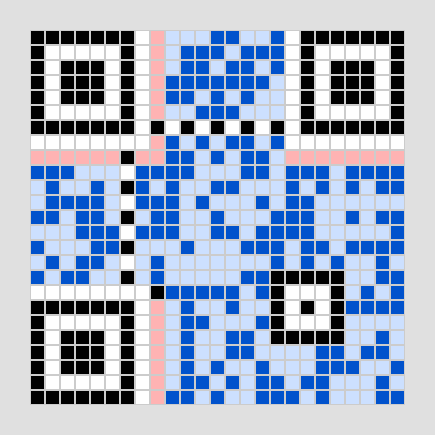

In [359]:
print("【ステップ1：マスク処理（市松模様）の適用】")

# mapping にはデータ領域の座標だけが入っているので、固定パターンは破壊されません
for (x, y) in mapping:
    if (x + y) % 2 == 0:
        # データ黒(2)ならデータ白(3)へ、白(3)なら黒(2)へ反転
        if matrix[y][x] == 2:
            matrix[y][x] = 3
        elif matrix[y][x] == 3:
            matrix[y][x] = 2

show_grid("ステップ1: マスク処理適用後（データが均等に散らばります）")

### 4.2 フォーマット情報の計算
今回のQRコードの設定である「誤り訂正レベルQ」と「マスクパターン000」を示す5ビットのデータに、
10ビットの誤り訂正符号（BCH符号）をくっつけて、15ビットのフォーマット情報を作成します。

In [360]:
print("【ステップ2：フォーマット情報の計算】")

# 誤り訂正レベルQ は 11(2進数)、マスクパターン000 は 000(2進数)。
# 結合すると 11000 となり、10進数で 24 です。
format_data = 0b11000

# 10ビットのBCH符号を計算（ここでも多項式の割り算が行われます）
# 生成多項式は規格で 10100110111 と決まっています。
data = format_data << 10
generator = 0b10100110111 << 4

for i in range(5):
    if data & (1 << (14 - i)):
        data ^= (generator >> i)

# 上位5ビット(設定値)と、下位10ビット(BCH符号)を結合
format_code = (format_data << 10) | data

# 最後に、読み取り精度を上げるための指定マスク(101010000010010)でXOR演算
format_code ^= 0b101010000010010

# 15文字の01の文字列に変換
format_bits = format(format_code, '015b')
print(f"算出された15ビットのフォーマット情報: {format_bits}")

【ステップ2：フォーマット情報の計算】
算出された15ビットのフォーマット情報: 011010101011111


【ステップ3：フォーマット情報の配置】
--- ステップ3: フォーマット情報の配置完了（赤い領域が埋まりました） ---


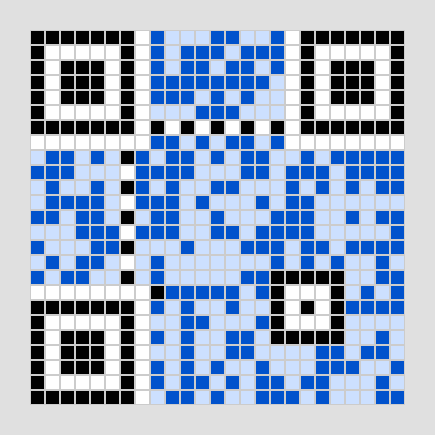

In [361]:
# 算出した15ビットの情報を、ファインダパタンの周囲（赤く塗っておいた予約領域）に配置します。

print("【ステップ3：フォーマット情報の配置】")

# 15ビットの配置座標リスト（規格で決まっています。タイミングパターンを避ける変則的な座標に注目）
# 左上ファインダパタンの周り
format_coords_1 = [
    (0,8), (1,8), (2,8), (3,8), (4,8), (5,8), (7,8), (8,8), (8,7), (8,5), (8,4), (8,3), (8,2), (8,1), (8,0)
]
# 右上および左下ファインダパタンの隣
format_coords_2 = [
    (8,24), (8,23), (8,22), (8,21), (8,20), (8,19), (8,18), (17,8), (18,8), (19,8), (20,8), (21,8), (22,8), (23,8), (24,8)
]

for i in range(15):
    bit = int(format_bits[i])
    val = 2 if bit == 1 else 3 # データ領域と同じく 2:黒, 3:白 として扱う

    # 同じ情報を2箇所に書き込む（片方が汚れても読み取れるようにするため）
    x1, y1 = format_coords_1[i]
    matrix[y1][x1] = val

    x2, y2 = format_coords_2[i]
    matrix[y2][x2] = val

show_grid("ステップ3: フォーマット情報の配置完了（赤い領域が埋まりました）")

### 4.3 最終画像の生成と読み取りテスト！
全てのデータが揃いました。デバッグ用の色分けをやめて、「黒」と「白」だけで画像を出力します。

【ステップ4：スマホで読み取れる最終画像の生成】

完成おめでとうございます！お手持ちのスマートフォンでスキャンしてみてください。


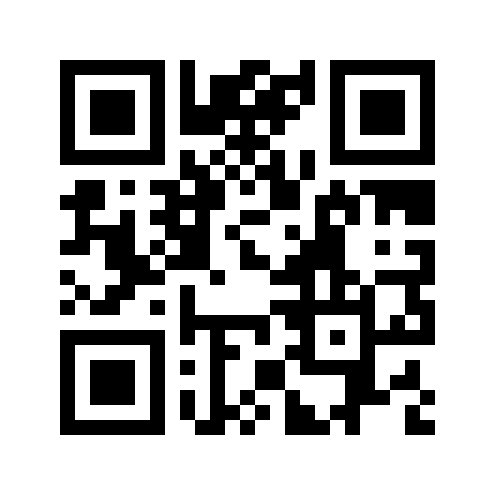

画像ファイル 'qr_tukumo.png' を保存しました。


In [ ]:


print("【ステップ4：スマホで読み取れる最終画像の生成】")

def create_scannable_image(filename="qr_hello.png"):
    scale = 15
    # スマホのカメラがQRコードを認識するには、周囲に十分な余白（クワイエットゾーン）が必要です。
    padding = 60 
    img_size = GRID_SIZE * scale + 2 * padding
    img = Image.new("RGB", (img_size, img_size), "white")
    draw = ImageDraw.Draw(img)

    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = matrix[y][x]
            px = padding + x * scale
            py = padding + y * scale
            box = [px, py, px + scale - 1, py + scale - 1]

            # 1(固定の黒) と 2(データの黒) を純粋な黒で塗りつぶす
            if val == 1 or val == 2:
                draw.rectangle(box, fill="black")

    print("\n完成おめでとうございます！お手持ちのスマートフォンでスキャンしてみてください。")
    display(img)
    img.save(filename)
    print(f"画像ファイル '{filename}' を保存しました。")


create_scannable_image()

# 5. おまけと参考資料

### 5.1 ジグザグのマッピングを可視化

マッピング図を保存しました: zigzag_mapping.png


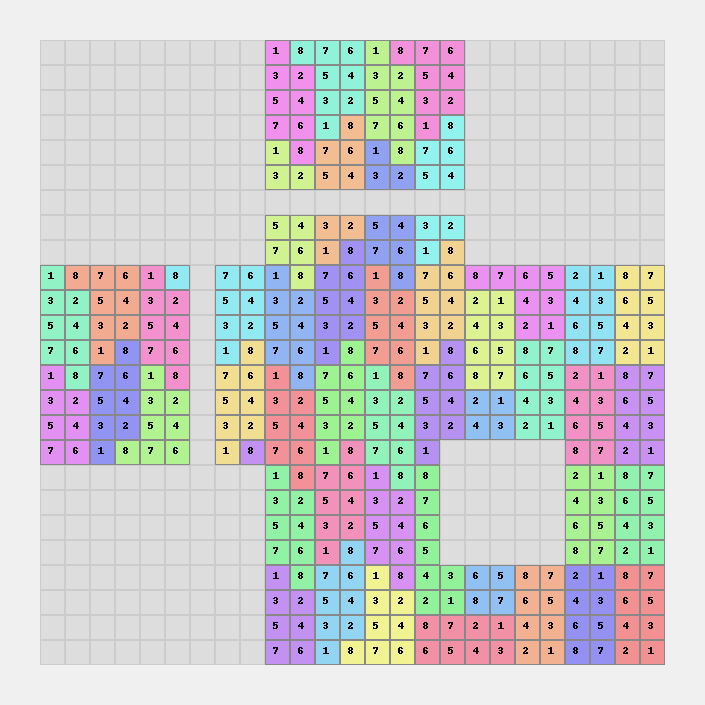

In [363]:
import colorsys
from PIL import Image, ImageDraw, ImageFont

def generate_mapping_diagram(filename="zigzag_mapping.png"):
    GRID_SIZE = 25
    scale = 25  # 数字を描画するため、マス目を少し大きめに設定
    padding = 40
    img_size = GRID_SIZE * scale + 2 * padding
    
    # 画像と描画ツールの初期化
    img = Image.new("RGB", (img_size, img_size), "#F0F0F0")
    draw = ImageDraw.Draw(img)
    
    # デフォルトフォントの読み込み
    font = ImageFont.load_default()

    def is_reserved(x, y):
        """V2における固定パターンや予約領域を判定してスキップするための関数"""
        # 左上 (ファインダパタン + セパレータ + フォーマット情報)
        if x <= 8 and y <= 8: return True
        # 右上 (ファインダパタン + セパレータ + フォーマット情報)
        if x >= 17 and y <= 8: return True
        # 左下 (ファインダパタン + セパレータ + フォーマット情報 / ダークモジュール含む)
        if x <= 8 and y >= 17: return True
        # タイミングパターン
        if x == 6 or y == 6: return True
        # アライメントパターン (V2)
        if 16 <= x <= 20 and 16 <= y <= 20: return True
        return False

    # ジグザグスキャンのルート計算
    mapping = []
    x = GRID_SIZE - 1
    upward = True
    
    while x > 0:
        if x == 6: x -= 1  # タイミングパターンの列をスキップ
        
        y_range = range(GRID_SIZE - 1, -1, -1) if upward else range(GRID_SIZE)
        for y in y_range:
            for dx in (0, -1):
                if not is_reserved(x + dx, y):
                    mapping.append((x + dx, y))
        upward = not upward
        x -= 2

    # 1. 予約領域をグレーで塗りつぶす（背景）
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            if is_reserved(x, y):
                px = padding + x * scale
                py = padding + y * scale
                draw.rectangle([px, py, px + scale - 1, py + scale - 1], 
                               fill="#DDDDDD", outline="#CCCCCC")

    # 2. ルートに従って色と数字を配置する
    for i, (x, y) in enumerate(mapping):
        byte_idx = i // 8   # 何バイト目か (0スタート)
        bit_idx = i % 8     # バイト内の何ビット目か (0〜7)
        
        # バイトごとに隣接しないハッキリとした色（HSV色空間）を生成
        hue = (byte_idx * 137.508) % 360  # 黄金角を使って色を散らす
        r, g, b = colorsys.hsv_to_rgb(hue / 360, 0.4, 0.95)
        color = (int(r * 255), int(g * 255), int(b * 255))
        
        px = padding + x * scale
        py = padding + y * scale
        
        # マスを色で塗る
        draw.rectangle([px, py, px + scale - 1, py + scale - 1], 
                       fill=color, outline="#888888")
        
        # マスの中に数字 (1〜8) を描画
        text = str(bit_idx + 1)
        
        # 数字をマスの中心付近に配置 (微調整)
        draw.text((px + 8, py + 5), text, fill="#000000", font=font)

    # 保存と表示
    img.save(filename)
    print(f"マッピング図を保存しました: {filename}")
    
    # Jupyter等でインライン表示できるならする。
    try:
        from IPython.display import display
        display(img)
    except ImportError:
        img.show()

# スクリプト単体で実行可能
if __name__ == "__main__":
    generate_mapping_diagram()

### 5.-1 参考文献

本記事のコード実装およびQRコードの仕様解読にあたり、以下の文献やサイトを参考にしています。より深く原理を知りたい方はぜひご参照ください。

### 当シリーズの過去記事
* **[QRコードの作り方を徹底解説｜"HELLO"を例にエンコーダをゼロから実装する](https://tukumolog.com/qr-code-encode-tutorial/)**
  * 本記事の前編となるエンコード処理の解説記事です。データの埋め込みやリードソロモン符号の付加過程をステップバイステップで解説しています。
* **[デジタル世界の数学「ガロア体」を超ざっくり理解しよう！](https://tukumolog.com/reed-solomon-galois-field-basics/)**
  * 今回のデコード計算でも活躍した「ガロア体（GF(2^8)）」の基礎理論を分かりやすく解説しています。

### 公式規格
* **[JIS X 0510:2018 (ISO/IEC 18004:2015) 二次元コードシンボル－QRコード－基本仕様](https://kikakurui.com/x0/X0510-2018-01.html)**
  * QRコードの公式な規格書（JIS規格）です。マスクパターンの計算式やデータ配置の厳密なルールについてはこちらを参照しています。

### 専門書・技術解説（リードソロモン符号・ガロア体）
* **[ガロア体入門 (Theoretical Background)](https://theoretical-background.com/%E3%82%AC%E3%83%AD%E3%82%A2%E4%BD%93%E5%85%A5%E9%96%80/)**
  * ガロア体上の多項式演算など、数学的背景について非常に詳しくまとめられているサイトです。